JUDY WAIRIMU NJUKU  
judynjuku7@gmail.com  
FINAL PROJECT PART 2 : CASTING DEFECT DETECTOR MODEL.

Loading Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
import sys
print(sys.executable)

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Scripts\python.exe


Defining dataset paths and parameters

In [3]:
base_dir = 'casting_product_image_data'  
train_dirs = [os.path.join(base_dir, 'train'), os.path.join(base_dir, 'casting_512x512')] 
test_dir = os.path.join(base_dir, 'test')
image_size = (128, 128)
batch_size = 32

Creating training dataset

In [4]:
import os

train_dirs = [os.path.join(base_dir, 'train'), os.path.join(base_dir, 'casting_512x512')]
test_dir = os.path.join(base_dir, 'test')

print(f"Base directory (from Cell 2): {base_dir}")
print(f"Train directory 1 (from train folder): {train_dirs[0]}")
print(f"Train directory 2 (casting_512x512): {train_dirs[1]}")
print(f"Test directory: {test_dir}")

train_datasets = []
for train_dir in train_dirs:
    print(f"Attempting to load training data from: {train_dir}")
    try:
        train_dataset = image_dataset_from_directory(
            train_dir,
            labels='inferred',
            label_mode='binary',  
            image_size=image_size,
            batch_size=batch_size,
            shuffle=True
        )
        train_datasets.append(train_dataset)
        print(f"Successfully loaded training data from: {train_dir}")
    except FileNotFoundError as e:
        print(f"Error: Could not find training directory: {train_dir}")
        print(f"Details: {e}")
        exit()

if len(train_datasets) > 1:
    train_dataset = train_datasets[0].concatenate(train_datasets[1])
elif len(train_datasets) == 1:
    train_dataset = train_datasets[0]
else:
    print("Error: No training data loaded.")
    exit()

Base directory (from Cell 2): casting_product_image_data
Train directory 1 (from train folder): casting_product_image_data\train
Train directory 2 (casting_512x512): casting_product_image_data\casting_512x512
Test directory: casting_product_image_data\test
Attempting to load training data from: casting_product_image_data\train
Found 6633 files belonging to 2 classes.
Successfully loaded training data from: casting_product_image_data\train
Attempting to load training data from: casting_product_image_data\casting_512x512
Found 1300 files belonging to 2 classes.
Successfully loaded training data from: casting_product_image_data\casting_512x512


Loading test dataset

In [5]:
try:
    test_dataset = image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='binary',
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False
    )
except FileNotFoundError as e:
    print(f"Error: Could not find test directory: {test_dir}")
    print(f"Details: {e}")
    exit()

Found 715 files belonging to 2 classes.


Configure the dataset for performance

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Standardizing the data

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

normalized_train_dataset = train_dataset.map(lambda image, label: (normalization_layer(image), label))
normalized_test_dataset = test_dataset.map(lambda image, label: (normalization_layer(image), label))

Building the CNN model

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compiling the model

In [9]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Training the model

In [10]:
epochs = 10  
history = model.fit(
    normalized_train_dataset,
    epochs=epochs,
    validation_data=normalized_test_dataset
)

Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 80s 297ms/step - accuracy: 0.5843 - loss: 0.6851 - val_accuracy: 0.8042 - val_loss: 0.4193
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 91s 364ms/step - accuracy: 0.8447 - loss: 0.3356 - val_accuracy: 0.9818 - val_loss: 0.0808
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 77s 309ms/step - accuracy: 0.9397 - loss: 0.1574 - val_accuracy: 0.9804 - val_loss: 0.0617
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.9698 - loss: 0.0892 - val_accuracy: 0.9818 - val_loss: 0.0562
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 278ms/step - accuracy: 0.9704 - loss: 0.0856 - val_accuracy: 0.9916 - val_loss: 0.0335
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 297ms/step - accuracy: 0.9848 - loss: 0.0497 - val_accuracy: 0.9497 - val_loss: 0.0970
Epoch 7/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 70s 281ms/step - accuracy: 0.9765 - loss: 0.0640 - val_accuracy: 0.9846 - val_loss: 0.0592
Epoch 8/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 73s 294ms/step - accuracy: 0.9877 - loss: 0

Visualize training history

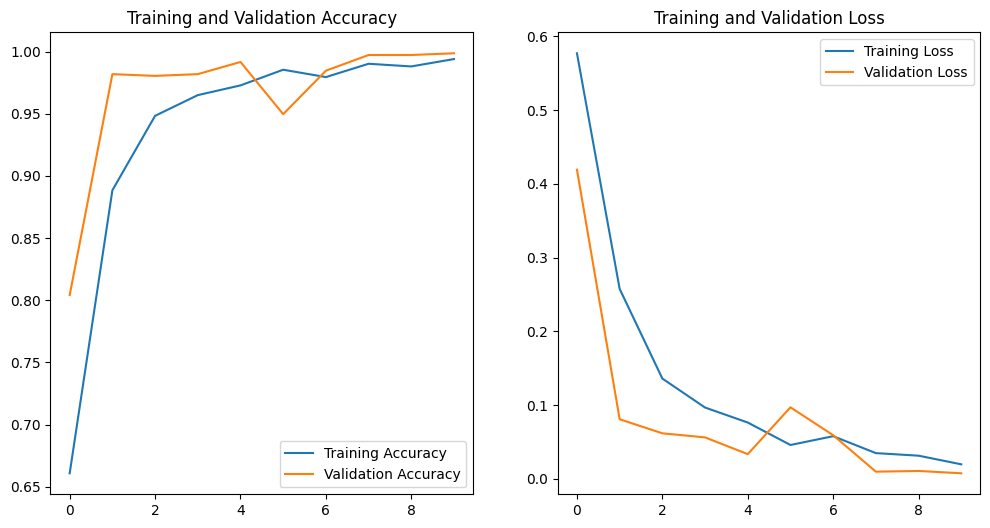

In [11]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Evaluating the model on the test set

In [12]:
loss, accuracy = model.evaluate(normalized_test_dataset)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9996 - loss: 0.0039
Test Loss:     0.0076
Test Accuracy: 0.9986


Saving the model

In [13]:
model.save('casting_defect_detector_model.keras')

Downloading modules for a python desktop application

In [14]:
!pip install pillow


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!pip install opencv_python


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing libraries

In [16]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
import tensorflow as tf
import cv2  

Loading the trained model

In [17]:
model = tf.keras.models.load_model('casting_defect_detector_model.keras')

Defining the image loading and processing function

In [18]:
def load_and_preprocess_image(image_path):
    try:
        img = Image.open(image_path).resize((128, 128))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0) 
        return img_array
    except Exception as e:
        print(f"Error loading or preprocessing image: {e}")
        return None

Defining the prediction function

In [19]:
def predict_image(image_path):
    processed_image = load_and_preprocess_image(image_path)
    if processed_image is not None:
        prediction = model.predict(processed_image)[0][0]
        if prediction > 0.5:
            return "Okay", prediction
        else:
            return "Defective", prediction
    else:
        return "Error", 0.0

Defining the image upload function

In [20]:
def upload_image():
    file_path = filedialog.askopenfilename()
    if file_path:
        try:
            img = Image.open(file_path).resize((200, 200))
            img_tk = ImageTk.PhotoImage(img)
            image_label.config(image=img_tk)
            image_label.image = img_tk
            prediction_result.config(text="") 
            global current_image_path
            current_image_path = file_path
        except Exception as e:
            print(f"Error loading image for display: {e}")
            prediction_result.config(text=f"Error loading image.")
            current_image_path = None

Defining the prediction button click function

In [21]:
def predict_button_clicked():
    if current_image_path:
        result, probability = predict_image(current_image_path)
        if result != "Error":
            prediction_result.config(text=f"Prediction: {result} (Probability: {probability:.2f})")
    else:
        prediction_result.config(text="Please upload an image first.")

Setting up the graphical user interface

MODEL DEPLOYMENT

In [22]:
!pip install PyQt5


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
